In [ ]:
import sys
import importlib.metadata as metadata

print("Python :", sys.version)
print("wordcloud :", metadata.version("wordcloud"))
print("Pillow :", metadata.version("Pillow"))

Mounted at /content/drive


In [ ]:
%pip install --no-cache-dir --force-reinstall \
    "Pillow==12.3.0" \
    "wordcloud==1.9.6"

In [ ]:
# Drive mount

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import seaborn as sns
import pandas as pd
from matplotlib import pyplot as plt
!pip install japanize-matplotlib
import japanize_matplotlib

In [ ]:
!pip install pdfplumber
!pip install pdfplumber pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 67.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 103.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 103.6 MB/s eta 0:00:00
  Attempting uninstall: Pillow
    Found existing installation: pillow 11.3.0
    Uninstalling pillow-11.3.0:
      Successfully uninstalled pillow-11.3.0


pdfフアイルを読み込む

In [ ]:
# extract_tables()は、「表単位」で夜も混む
# row[0]  # 1列目：性別 row[1]  # 2列目：年齢 row[2]  # 3列目：居住地区 row[3]  # 4列目：市民の声

import pdfplumber

# PDFファイルのパス
path = "/content/drive/MyDrive/38_自然言語処理/市民アンケート(2026)/2026/"
name = "R6_市民調査(自由意見).pdf"
pdf_name = path + name

citizen_voices = []

with pdfplumber.open(pdf_name) as pdf:
    for page in pdf.pages:
        for table in page.extract_tables():   # １つの表を指定

            for row in table:   # 表の中の１行（１レコード）を読む
                # 男性・女性で始まるデータ行から、4列目row[3] を「市民の声」だけ取得
                if row and len(row) >= 4 and row[0] in ["男性", "女性"]:
                   voice = row[3]
                   if voice is None:
                      voice = ""
                   voice = voice.replace("\n", "")
                   voice = voice.strip()
                   if voice:
                        citizen_voices.append(voice)

print("抽出件数：", len(citizen_voices))

for voice in citizen_voices:
    print(voice)

抽出件数： 105
美原町の街灯が少ない夜道怖い
高坂駅から出るバスの本数が少ない。（特に土日、祝、夜23：00頃までの時間）デマンドタクシー等の公共交通サービスを充実させてほしい。
私の住んでいる地域では、道路に歩道がなく、安心して子どもと歩くことができない道路があります。また、街灯が少なく、車を運転していると歩行者が見えにくいことがあります。こうした部分の整備を駅前などの主要地域以外の場所でも進めていただけると有難いと思います。
小学生が夏休みに遊ぶことのできる施設が極端に少ないと感じます。暑い最中、外で遊ぶこともできず、ソーレやマーレにも入れないとなると、暑い日の遊び場が商業施設しかなくあまり毎日のようには連れて行けません。小学生でも使える安全で比較的利用料が安価な施設があると嬉しいです。
若松町一丁目交差点を改善してほしい。（歩行者分離、矢印信号など信号が変わっても右折の車が途切れないことがよくあって危ない）
市内の渋滞する箇所を解消してほしい。特に南中学校の交差点！
新しく整備されたにも関わらず、危なく感じる交差点や道路があります。小学生の通学路なのに、車がけっこうなスピードで通り抜けるようになった箇所もあるので、見直しをしていただきたいです。また、駅前で食料品を買えるお店がないので、誘致できるといいと思います。
今は自家用車で移動できますが、高齢になったらバスやデマンドタクシーを利用したいと考えていますが、今後高齢化に伴いバスの運行数を増やしたり利用券等の数を増やしてもらえたら、安心して東松山市で生活できると思います。それから、南中の右折帯ができて良かったです。
市内バスのバス停を増やして欲しい。
近所に新しい戸建て住宅の建築工事がたくさんあり、これからも発展していく街なんだなと感じています。近所にスーパーや電気店、ホームセンター、レストラン等があり生活しやすいところで満足しています。バス停が近くにないので、もっとバス停が増えると良いなと思っています。
道路整備や下水道整備について、予算のこともあるでしょうが現実的に困っている地域があります。若い世代の転入を望んでも環境条件で入ってもらえません。市の基準を全面に出して手を出さないのではなく、東松山市を住み良い街にするために市の中心部以外にも目配りをしていただきたいと思います。その結果で東松山市の評価が上が

テキストフアイルに保存

In [ ]:
# テキストフアイルに保存

path = "/content/drive/MyDrive/38_自然言語処理/市民アンケート(2026)/2026/"
name = "R6_市民調査(自由意見).txt"
output_file = path + name

with open(output_file, "w", encoding="utf-8-sig") as file:
    for voice in citizen_voices:
        file.write(voice + "\n")

print("保存しました：", output_file)

In [ ]:
!pip install janome
from janome.tokenizer import Tokenizer
from collections import Counter

# 市民の声を分析する。　形態素解析して単語を数える

In [ ]:
# 形態素解析して単語を数える

tokenizer = Tokenizer()

# 表示する単語数
TOP_N = 30

# 集計から除外する単語
stop_words = {
    "こと", "もの", "ため", "よう", "の", "的", "私"
    "等", "人", "市", "東松山", "東松山市"
}

words = []

# 市民の声を1件ずつ処理
for one_voice in citizen_voices:

    # 文章を単語に分ける
    for token in tokenizer.tokenize(one_voice):

        # 品詞情報を取得
        part = token.part_of_speech.split(",")

        # 名詞だけを取り出す
        if part[0] == "名詞":

            word = token.surface  # 文章を単語に分割する

            # 不要な単語を除外
            if word not in stop_words:
                words.append(word)

# 単語の出現回数を数える
word_counts = Counter(words)

# 頻度の高い順に表示
for word, count in word_counts.most_common(TOP_N):
    print(word, count)

施設 30
人 19
的 18
駅 16
街 16
整備 15
等 14
利用 14
子供 13
道路 12
町 11
店 11
づくり 11
市内 10
市役所 10
充実 9
私 9
場所 9
生活 9
周辺 9
市民 9
バス 8
地域 8
者 8
商業 8
化 8
環境 8
大変 8
まち 8
子育て 8


WordCloudで可視化する

In [ ]:
from wordcloud import WordCloud

print("正常に読み込めました")

正常に読み込めました


In [ ]:
# 日本語フォントの場所を取得
from pathlib import Path
font_folder = Path(japanize_matplotlib.__file__).parent
font_path = next(font_folder.rglob("ipaexg.ttf"))


Word_cloudeを使って単語頻度を可視化する

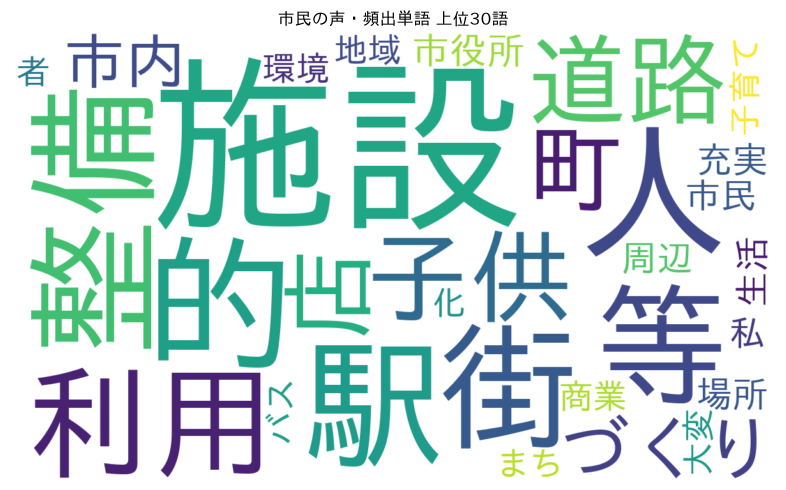

In [ ]:
# Word Cloude

# Word Cloudに表示する単語数
TOP_N = 30


# 頻度の高い上位単語を取り出す
frequencies = dict(word_counts.most_common(TOP_N))

# Word Cloudを作成
wordcloud = WordCloud(
    font_path=str(font_path),
    width=1200,
    height=700,
    background_color="white",
    colormap="viridis",
    max_words=TOP_N,
    collocations=False,
    random_state=42
).generate_from_frequencies(frequencies)

# 表示
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title(f"市民の声・頻出単語 上位{TOP_N}語")
plt.tight_layout()
plt.show()


In [ ]:
# 画像として保存する場合

path = "/content/drive/MyDrive/38_自然言語処理/市民アンケート(2026)/2026/"
plt.savefig(
    path + "市民の声_wordcloud.png",
    dpi=200,
    bbox_inches="tight"
)

In [ ]:
# ------------------
# mecabのインストール
# -------------------

!apt-get install mecab libmecab-dev mecab-ipadic-utf8 -y
!pip install mecab-python3
!pip install unidic-lite
!pip install janome

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libmecab-dev is already the newest version (0.996-14build9).
mecab-ipadic-utf8 is already the newest version (2.7.0-20070801+main-3).
mecab is already the newest version (0.996-14build9).
0 upgraded, 0 newly installed, 0 to remove and 1 not upgraded.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.7/19.7 MB 54.6 MB/s eta 0:00:00


In [ ]:
# -------------------------------------------
# MeCab
# 分かち書き(単語のくぎりに空白をいれる表記方法)
# --------------------------------------------

#トークン化ツールをインスタンス化
# MeCabのインポート
import MeCab

# パーサーの引数に-Owakatiを指定[分かち書き]
meca = MeCab.Tagger("-Owakati /var/lib/mecab/dic/ipadic-utf8")

#　文章の定義
text = "私は毎日コーヒーを飲みます。"

# 変数textの分かち書きを行う
ans = meca.parse(text)

# 結果の表示
print(ans)

私 は 毎日 コーヒー を 飲み ます 。 



In [ ]:
# MeCabを使った形態素解析 カタカナに変換

# MeCabのインポート
import MeCab

# パーサーの設定
# -Oyomi オプションで読み仮名を取得します
m = MeCab.Tagger("-Oyomi -d /var/lib/mecab/dic/ipadic-utf8")

# 文章の定義
text = "東海道新幹線 一部区間で運転見合わせ 名古屋駅～岐阜羽島駅間"
# 変数textの形態素解析を行う
katakana = m.parse(text)

# 結果の表示
print(katakana)


トウカイドウシンカンセン イチブクカンデウンテンミアワセ ナゴヤエキ～ギフハシマエキカン



日本語、単語の重要度を計算する

In [ ]:
import pandas as pd
from janome.tokenizer import Tokenizer
from sklearn.feature_extraction.text import TfidfVectorizer

# 形態素解析器の初期化
t = Tokenizer()

# 名詞・動詞・形容詞の原形のみを抽出するトークナイザー関数
def ja_tokenizer(text):
    tokens = []
    for token in t.tokenize(text):
        part_of_speech = token.part_of_speech.split(",")[0]
        if part_of_speech in ["名詞", "動詞", "形容詞"]:
            tokens.append(token.base_form)  # 原形（基本形）を採用
    return tokens

# 文書の定義（動作確認用にdocumentBも定義）
documentA = "ネコが机の上に座っています"
documentB = "イヌが庭を走っています"

# tokenizer引数に日本語用の関数を渡す
vectorizer = TfidfVectorizer(tokenizer=ja_tokenizer, token_pattern=None)

# fit & transform
vectors = vectorizer.fit_transform([documentA, documentB])

# 単語リストの取得
feature_names = vectorizer.get_feature_names_out()

# データフレーム型に変換
df = pd.DataFrame(vectors.toarray(), columns=feature_names)

display(df)



,いる,イヌ,ネコ,上,座る,庭,机,走る
0,0.335176,0.000000,0.471078,0.471078,0.471078,0.000000,0.471078,0.000000
1,0.379978,0.534046,0.000000,0.000000,0.000000,0.534046,0.000000,0.534046
